___

# <font color= #EF4444> **Speech Radicalization Analysis** </font>
#### <font color= #f0565e> `Deep Learning`</font>
<Strong> Sofía Maldonado, Oscar Josué Rocha & Viviana Toledo </Strong>

_12/05/2026._

___

# <font color= #EF4444> **Import Libraries & Data** </font>

In [1]:
# General
import numpy as np
import pandas as pd
from datasets import Dataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# Modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

/home/vivienne/apps/deep-learning/speech_radicalization_analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "vinai/bertweet-base"

In [3]:
df = pd.read_csv('../data/processed/speech_classified.csv')
df = df[['clean_text', 'annotation_label']]
df

,clean_text,annotation_label
0,"china, this is what you are known for: animalr...",Hate Speech
1,catabuserschina visa workers and their employe...,Hate Speech
2,china madeinchina chinatravel china doesn't ha...,Extreme Speech
3,"they are ugly psychopaths, monsters!!!",Extreme Speech
4,and its culture of cruelty and brutality,Hate Speech
...,...,...
6213,its time for our weekly economic update on isr...,Hate Speech
6214,any doubt....,Hate Speech
6215,not this republican. neveragain allow another ...,Hate Speech
6216,"that's one way to filter your feed, i guess. p...",Enraged Speech


In [4]:
X = df['clean_text'].tolist()
y = df['annotation_label'].tolist()

# <font color= #EF4444> **Preprocessing** </font>

To start, let's map the labels to use as future reference:

In [5]:
# Initialize label encoder
label_encoder = LabelEncoder()

# Fit label encoder
y_label = label_encoder.fit_transform(y)

# Num of labels
num_labels = len(label_encoder.classes_)

# Show label mapping
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
mapping

{np.str_('Dangerous Speech'): np.int64(0),
 np.str_('Enraged Speech'): np.int64(1),
 np.str_('Extreme Speech'): np.int64(2),
 np.str_('Hate Grammar'): np.int64(3),
 np.str_('Hate Speech'): np.int64(4),
 np.str_('Horror Grammar'): np.int64(5)}

Before tokenizing, let's do a train-test-split and convert the data to hugging face datasets:

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.2, random_state=69, stratify=y)

In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([ 3.8028,  1.6580,  2.0934,  7.7477,  0.2231, 21.8158])


In [8]:
train_dataset = Dataset.from_dict({
    "text": X_train,
    "label": y_train
})

test_dataset = Dataset.from_dict({
    "text": X_test,
    "label": y_test
})

Next, it's needed to tokenize the data:

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding = 'max_length',
        truncation = True,
        max_length = 128,
    )

train_dataset = train_dataset.map(tokenize, batched = True)
test_dataset = test_dataset.map(tokenize, batched = True)

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Map: 100%|██████████| 1244/1244 [00:00<00:00, 4821.88 examples/s]


In [10]:
# Preprare data for pytorch loading
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# <font color= #EF4444> **Modeling** </font>

Then we save the bert-tweet model using a pretrained model with sequence classification

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels = num_labels)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 40081.39it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing 

Our metrics to evaluate this model are, accuracy, f1, precision and recall

In [12]:
# Function to compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='weighted'
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        'Accuracy': accuracy,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

The next step is just save the results 

In [14]:
training_args = TrainingArguments(
    # Store Results
    output_dir="../models/results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    # Log Epochs
    save_total_limit=1,
    logging_dir="../models/logs",
    logging_steps=50,

    fp16=torch.cuda.is_available()
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Focal loss es una funcion enfocada para problemas con clases desbalanceadas. utiliza cross entropy para obtener la loss de cada muestra, con esto procede a ponderar los valores para darle más o menos importancia a una clase o a otra, restandole importancia a los ejemplos faciles de clasificar y manteniendo a los que son dificiles de clasificar.

In [15]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=None, gamma=2):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):

        ce_loss = F.cross_entropy(
            logits,
            labels,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

La funcion weighted trainer se encarga de pasar los resultados del modelo por nuestra anterior funcion de focalloss, enfocandose en los ejemplos complicados de clasificar e ignorando a los faciles, gracias al gamma 2.

In [16]:
class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = FocalLoss(
            alpha=class_weights.to(model.device),
            gamma = 2,
        )

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [17]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.037116,0.834877,0.213826,0.127000,0.731202,0.213826
2,0.676667,0.813904,0.416399,0.438372,0.819500,0.416399
3,0.705184,0.776395,0.531350,0.572694,0.835806,0.531350
4,0.380363,0.801074,0.631029,0.674858,0.844820,0.631029
5,0.047252,0.721817,0.743569,0.776029,0.867793,0.743569
6,0.095286,0.878719,0.748392,0.782625,0.871732,0.748392
7,0.070521,0.945917,0.778939,0.804975,0.871299,0.778939
8,0.023617,0.856141,0.825563,0.843454,0.880294,0.825563
9,0.043274,0.892729,0.810289,0.831134,0.877883,0.810289
10,0.005945,0.889303,0.823955,0.840896,0.876855,0.823955


/home/vivienne/apps/deep-learning/speech_radicalization_analysis/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]
/home/vivienne/apps/deep-learning/speech_radicalization_analysis/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


TrainOutput(global_step=3110, training_loss=0.35515169476509284, metrics={'train_runtime': 397.2293, 'train_samples_per_second': 125.217, 'train_steps_per_second': 7.829, 'total_flos': 3271903477585920.0, 'train_loss': 0.35515169476509284, 'epoch': 10.0})

In [18]:
results = trainer.evaluate()

results

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.005945,0.721817,10,0.743569,0.776029,0.867793,0.743569


{'eval_loss': 0.721816897392273,
 'eval_Accuracy': 0.7435691318327974,
 'eval_F1': 0.7760291348221167,
 'eval_Precision': 0.8677928821187738,
 'eval_Recall': 0.7435691318327974}

In [19]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

In [20]:
y_true_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

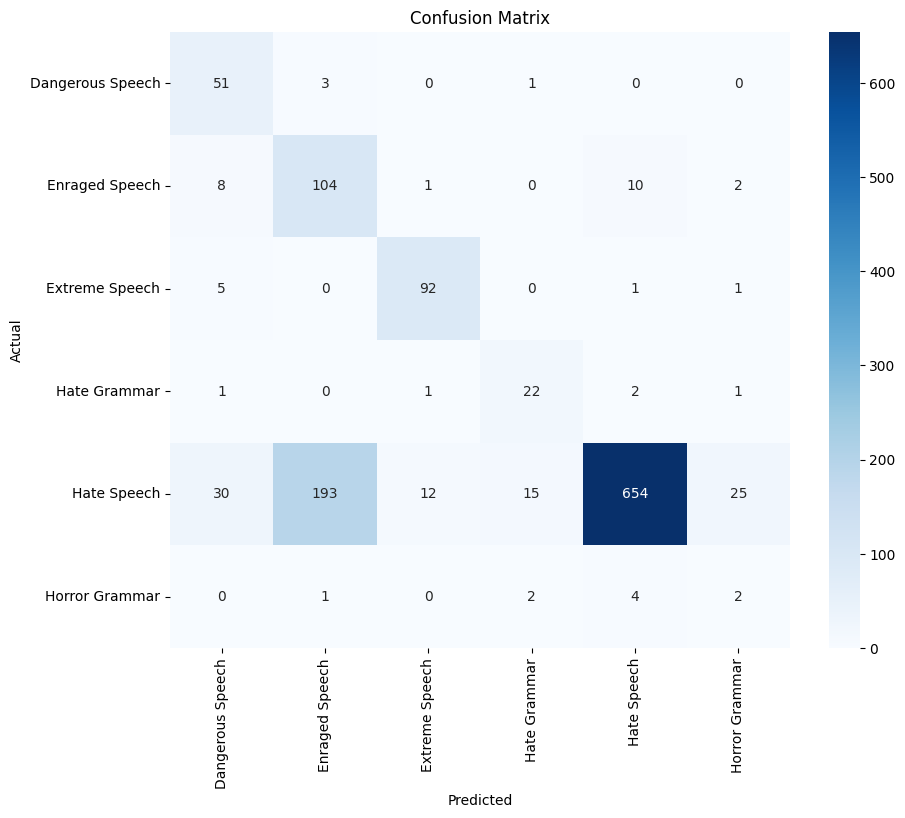

In [21]:
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
# Convert labels back to text
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Create dataframe
df_test_results = pd.DataFrame({
    "tweet": X_test,
    "true_label": true_labels,
    "predicted_label": pred_labels
})

# Save
df_test_results.to_csv("../data/processed/test_predictions.csv", index=False)

In [24]:
# Save tokenizer
tokenizer.save_pretrained("../models/results/checkpoint-1555")

('../models/results/checkpoint-1555/tokenizer_config.json',
 '../models/results/checkpoint-1555/vocab.txt',
 '../models/results/checkpoint-1555/bpe.codes',
 '../models/results/checkpoint-1555/added_tokens.json')